<a href="https://colab.research.google.com/github/Gbriel26/IA_TEMA_ML/blob/main/IA_TEMA_ML_5_(K_Means_Clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
# Cargan los datos
file_path = 'Customer-survey-data.csv'
data = pd.read_csv(file_path)

In [3]:
data.columns = [
    'Customer',
    'Delivery_Satisfaction',
    'Food_Quality',
    'Delivery_Speed',
    'Order_Accuracy'
]

data_cleaned = data.dropna(subset=['Delivery_Satisfaction', 'Food_Quality', 'Delivery_Speed', 'Order_Accuracy'])
data_cleaned['Order_Accuracy'] = data_cleaned['Order_Accuracy'].map({'Yes': 1, 'No': 0})

/tmp/ipython-input-868650574.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Order_Accuracy'] = data_cleaned['Order_Accuracy'].map({'Yes': 1, 'No': 0})


In [4]:
data.head()

,Customer,Delivery_Satisfaction,Food_Quality,Delivery_Speed,Order_Accuracy
0,1,5.0,3.0,4.0,Yes
1,2,3.0,4.0,3.0,Yes
2,3,4.0,5.0,2.0,Yes
3,4,5.0,3.0,4.0,Yes
4,5,2.0,5.0,1.0,Yes


In [5]:
# Seleccionar y normalizar características
features = ['Delivery_Satisfaction', 'Food_Quality', 'Delivery_Speed', 'Order_Accuracy']
X = data_cleaned[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Método del codo
inertia = []

k_values = range(1, 10)

In [8]:
# entrenamiento
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Añadimos n_init=10 para evitar warnings
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

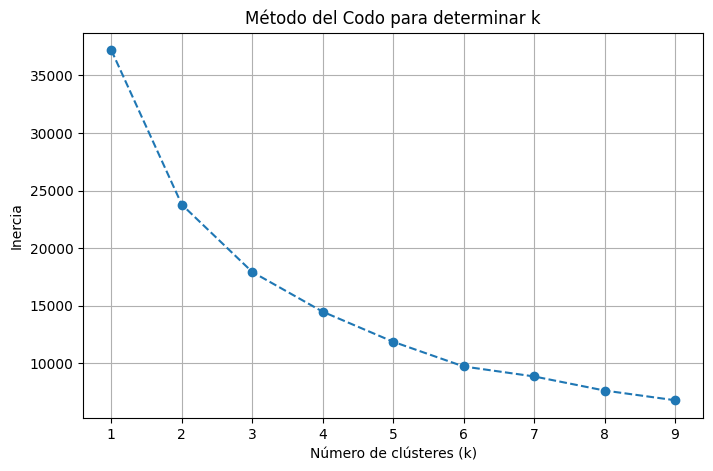

In [9]:
# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.title('Método del Codo para determinar k')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.xticks(k_values)
plt.grid()
plt.show()

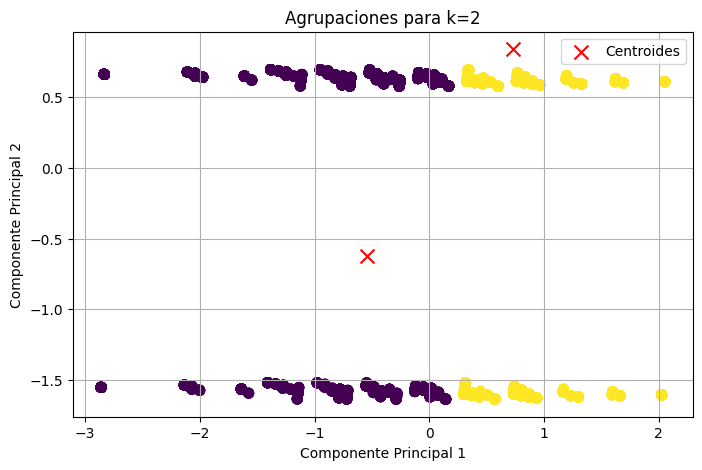

In [10]:
from sklearn.decomposition import PCA

# Reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Aplicar K-Means con k=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10) # Añadimos n_init=10
clusters_2 = kmeans_2.fit_predict(X_scaled)

# Crear el gráfico
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_2, cmap='viridis', s=50)
plt.scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], c='red', marker='x', s=100, label='Centroides')
plt.title('Agrupaciones para k=2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid()
plt.show()

In [12]:
# Centroides en el espacio original
centroides_k2 = kmeans_2.cluster_centers_

# Transformar los centroides de vuelta al espacio original (desnormalizar)
centroides_originales_k2 = scaler.inverse_transform(centroides_k2)

# Convertir los centroides en un DataFrame para facilitar la interpretación
centroides_df_k2 = pd.DataFrame(centroides_originales_k2, columns=features)
print("Centroides para k=2:")
print(centroides_df_k2)

Centroides para k=2:
   Delivery_Satisfaction  Food_Quality  Delivery_Speed  Order_Accuracy
0               2.543678      2.449559        2.448619        0.715010
1               4.363613      4.521137        4.493709        0.714897
